In [2]:
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
import torchvision.transforms.functional as VF
from PIL import Image
import time
import numpy as np

device = 'cuda'
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.8.0+cu128


In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [4]:
train_dataset = datasets.MNIST(
    root="./DATA",
    train=True,
    download=True,
    transform=transform)

test_dataset = datasets.MNIST(
    root="./DATA",
    train=False,
    download=True,
    transform=transform)    

100.0%
100.0%
100.0%
100.0%


In [14]:
train_dataset.__class__.mro()

[torchvision.datasets.mnist.MNIST,
 torchvision.datasets.vision.VisionDataset,
 torch.utils.data.dataset.Dataset,
 typing.Generic,
 object]

In [7]:
type(train_dataset)

torchvision.datasets.mnist.MNIST

In [125]:
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 1024)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(1024, 256)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.dropout1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)        
        return x

In [6]:
def test_model(model, dataloader, criterion):
    model.eval()
    running_loss_test = 0.0
    n_obs_test = 0
    for data, target in dataloader:
        data, target = data.to(device), target.to(device)
        output = model(data)
        loss = criterion(output, target)
        running_loss_test += loss.item() * len(data)
        n_obs_test += len(data)
    epoch_loss_test = running_loss_test / n_obs_test
    return epoch_loss_test

In [22]:
def gradient_noise_scale(model: nn.Module, dataset: torch.utils.data.dataset.Dataset, criterion: torch.nn.modules.module.Module, n: int, k: int):
    model.eval()
    data_loader=DataLoader(
        dataset=dataset,
        batch_size=k,
        shuffle=True,
        num_workers=0,
        pin_memory=False,
        persistent_workers=False,
        drop_last=True)
    grads = []
    data_iter = iter(data_loader)
    for i in range(n):
        try:
            data, label = next(data_iter)
        except StopIteration:
            data_iter = iter(data_loader)
            data, label = next(data_iter) 
        model.zero_grad()
        data, label = data.to(device), label.to(device)
        output = model(data)
        loss = criterion(output, label)
        loss.backward()
        grad_vector = torch.cat([p.grad.detach().flatten() for p in model.parameters()])
        grads.append(grad_vector)
    G = torch.stack(grads)
    grad_var = torch.var(G, dim=0)
    grad_mean = torch.mean(G, dim=0)
    S = grad_var.mean() / grad_mean.pow(2).mean()
    return S.item()
    

In [134]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    drop_last=True)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=512,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    drop_last=False)

In [138]:
n = 16
k = 256

model = SimpleNN().to(device)
optimizer = optim.AdamW(
    params=model.parameters(),
    lr=0.001,
    weight_decay=10
)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

exp_folder = f'runs/model_{int(time.time())}'
writer_train = SummaryWriter(f"{exp_folder}/train")
writer_valid = SummaryWriter(f"{exp_folder}/valid")
global_step = 0
beta1, beta2 = optimizer.param_groups[0]["betas"]
base_lr = optimizer.param_groups[0]["lr"]
eps = optimizer.param_groups[0]["eps"]
for epoch in range(50):
    running_loss = 0.0
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        running_loss += loss.item()

        # Log Params Batch
        total_param_norm = 0.0
        total_param_count = 0.0
        total_grad_norm = 0.0
        for name, param in model.named_parameters():
            if param.requires_grad:
                if "bias" in name:
                    short_name = name[:-5]
                    group_name = "Bias"
                else:
                    short_name = name[:-7]
                    group_name = "Weight"
                
                writer_train.add_scalar(f"{group_name}_param_norm_scaled/{short_name}", param.data.norm(2) / (param.data.numel() ** 0.5), global_step) 
                writer_train.add_scalar(f"{group_name}_gradient_norm/{short_name}", param.grad.data.norm(2), global_step) 

                total_param_norm += param.data.norm(2) ** 2
                total_param_count += param.data.numel()
                total_grad_norm += param.grad.data.norm(2) ** 2

                if global_step>0:
                    step = optimizer.state[param]['step'] 
                    m_t = optimizer.state[param]['exp_avg'] / (1 - beta1 ** step)
                    v_t = optimizer.state[param]['exp_avg_sq'] / (1 - beta2 ** step)
                    effective_update = base_lr * m_t / (v_t ** 0.5 + eps)
                    writer_train.add_scalar(f"{group_name}_update_ratio/{short_name}", effective_update.abs().mean() / param.detach().abs().mean(), global_step)
        
        writer_train.add_scalar(f"Total_norm/Param_scaled", (total_param_norm / total_param_count) ** 0.5, global_step) 
        writer_train.add_scalar(f"Total_norm/Gradient", total_grad_norm ** 0.5, global_step)
        writer_train.add_scalar("Loss/batch", loss.item(), global_step)
        
        global_step += 1
        clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step() 

    # Log Params Epoch
    for name, param in model.named_parameters():
        if param.requires_grad:
            if "bias" in name:
                short_name = name[:-5]
                group_name = "Bias"
            else:
                short_name = name[:-7]
                group_name = "Weight"
        writer_train.add_histogram(f"{group_name}_param/{short_name}", param.data.cpu(), epoch)
        writer_train.add_histogram(f"{group_name}_gradient/{short_name}", param.grad.data.cpu(), epoch)
    loss_train_epoch = running_loss / len(train_loader)
    writer_train.add_scalar("Loss/epoch", loss_train_epoch, epoch)

    loss_valid_epoch = test_model(model = model, dataloader = test_loader, criterion = criterion)
    writer_valid.add_scalar("Loss/epoch", loss_valid_epoch, epoch)

    S = gradient_noise_scale(
        model = model,
        dataset = train_dataset,
        criterion = criterion,
        n = n,
        k = k)
    writer_train.add_scalar("Optimal_batch", int(S*k), epoch)

    writer_train.add_scalar("LR", scheduler.get_last_lr()[0], epoch)
    scheduler.step()
    
writer_train.close()
writer_valid.close()

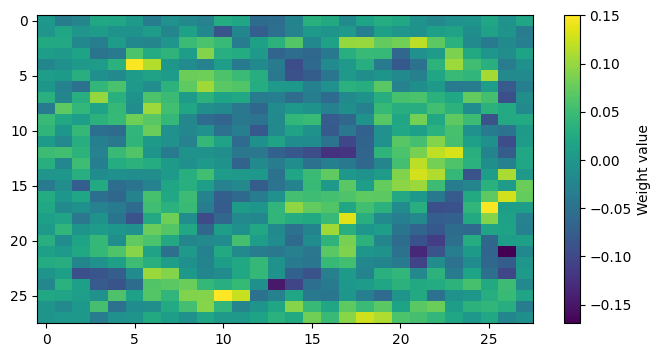

In [129]:
i = 1
data = model.fc1.weight.detach().cpu()[i, :].view(28, 28).cpu().numpy()
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
img = plt.imshow(data, cmap='viridis', aspect='auto')
plt.colorbar(img, label="Weight value")
plt.show()

In [131]:
(model.fc1.weight.detach().abs() < 0.01).to(torch.float32).mean()

tensor(0.1747, device='cuda:0')

In [137]:
??optim.AdamW

Init signature:
optim.AdamW(
    params: Union[collections.abc.Iterable[torch.Tensor], collections.abc.Iterable[dict[str, Any]], collections.abc.Iterable[tuple[str, torch.Tensor]]],
    lr: Union[float, torch.Tensor] = 0.001,
    betas: tuple[typing.Union[float, torch.Tensor], typing.Union[float, torch.Tensor]] = (0.9, 0.999),
    eps: float = 1e-08,
    weight_decay: float = 0.01,
    amsgrad: bool = False,
    *,
    maximize: bool = False,
    foreach: Optional[bool] = None,
    capturable: bool = False,
    differentiable: bool = False,
    fused: Optional[bool] = None,
)
Docstring:     
Implements AdamW algorithm, where weight decay does not accumulate in the momentum nor variance.

.. math::
   \begin{aligned}
        &\rule{110mm}{0.4pt}                                                                 \\
        &\textbf{input}      : \gamma \text{(lr)}, \: \beta_1, \beta_2
            \text{(betas)}, \: \theta_0 \text{(params)}, \: f(\theta) \text{(objective)},
            \: \e